# Arabam.com ikinci el otomobil fiyat regresyonu (gelişmiş)

**Veri:** `arabam.com-otomobil-veri-seti-csv.csv` — Türkiye geneli ilanlar (~180k satır, zengin şema)

**Hedef:** `fiyat_num` (TL)

**Akış:** EDA → `arabam_preprocess` → çoklu model → `RandomizedSearchCV` → 5-fold CV → özellik önemi → hata analizi → (opsiyonel) log1p / SHAP.

## Proje checklist (profesyonel DS prosedürü)

| Aşama | Durum |
|--------|--------|
| Problem tanımı (regresyon, MAE/RMSE/R²/MAPE) | Bu notebook |
| Veri sözlüğü ve sızıntı denetimi | Aşağıdaki tablo |
| Yükleme, tekil `listing_id`, hedef geçerliliği | Bölüm 1–3 |
| EDA (eksiklik, kardinalite, dağılım, korelasyon) | Bölüm 2 |
| Ön-işleme (sayısal/kategorik, OHE `max_categories`) | Bölüm 4 |
| Train/test + CV yalnızca train | Bölüm 3–6 |
| Baseline + doğrusal + ağaç + boosting | Bölüm 4 |
| Hiperparametre araması | Bölüm 5 |
| Önem, kalıntı, segment hatası | Bölüm 7 |
| Tekrarlanabilirlik (`random_state`, gereksinimler) | `requirements.txt` |
| Üretim | `train_model_arabam.py` → `artifacts_arabam/` |

## Veri sözlüğü ve modelde kullanım

| Ham sütun / grup | Modelde | Not |
|------------------|---------|-----|
| `listing_id` | Tekilleştirme sonrası düşürülür | — |
| `url`, `scraped_at`, `ilan_basligi`, `ilan_aciklamasi` | Kullanılmaz | Sızıntı / NLP dışı |
| `ilan_tarihi` | Kullanılmaz (bu sürüm) | İleride “ilan yaşı” türetilebilir |
| `fiyat` | `fiyat_num` (hedef) | Parse; %1–%99 winsorization |
| `km`, `yil` | `km_num`, `yil` | Aykırı yıl filtresi |
| `motor_hacmi`, `motor_gucu` | Sayısal parse | Aralık metinleri ortalama |
| `ort_yakit_tuketimi`, `yakit_deposu` | Sayısal | Eksik → imputation |
| 13 panel sütunu | `panel_*_n` sayıları | Orijinal/Boyalı/Değişen/Belirsiz |
| `marka` … `boya_degisen` | Kategorik | `OneHotEncoder(max_categories=50)` |

In [3]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (
    RandomizedSearchCV, cross_val_score, learning_curve, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

from arabam_preprocess import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    TARGET,
    enrich_arabam_dataframe,
    load_prepared_arabam_frame,
)

HIGH_CARD_CATS = ["marka", "seri", "model", "sehir", "ilce"]
LOW_CARD_CATS = [c for c in CATEGORICAL_FEATURES if c not in HIGH_CARD_CATS]

# Windows: RandomizedSearchCV n_jobs=-1 + XGBoost n_jobs=-1 ic ice -> WinError 1450
CV_PARALLEL_JOBS = 1 if os.name == "nt" else -1
# Hiperparametre aramasi: n_iter x cv fold = toplam fit (Windows'ta sirali -> uzun surer)
RANDOM_SEARCH_N_ITER = 12
RANDOM_SEARCH_CV = 2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
BASE = Path(".").resolve()
CSV_ARABAM = BASE / "arabam.com-otomobil-veri-seti-csv.csv"
CSV_CARS = BASE / "cars.csv"
print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 1. Ham veri yükleme ve ilk bakış

In [4]:
df_raw = pd.read_csv(CSV_ARABAM, encoding="utf-8", low_memory=False)
print("Boyut:", df_raw.shape[0], "satır ×", df_raw.shape[1], "sütun")
print("Bellek (yaklaşık MB):", df_raw.memory_usage(deep=True).sum() / 1e6)
display(df_raw.head(3))
df_raw.dtypes

Boyut: 180723 satır × 41 sütun
Bellek (yaklaşık MB): 701.466523


,listing_id,url,scraped_at,ilan_basligi,fiyat,sehir,ilce,ilan_aciklamasi,ilan_tarihi,marka,seri,yil,yakit_tipi,km,renk,arac_durumu,kasa_tipi,agir_hasarli,kimden,sag_arka_camurluk,...,sol_arka_camurluk,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon,vites_tipi,motor_hacmi,motor_gucu,cekis,takasa_uygun,boya_degisen,model,ort_yakit_tuketimi,yakit_deposu
0,36101543,https://www.arabam.com/ilan/sahibinden-satilik...,2026-03-18T21:04:55.033271+00:00,Sahibinden Yuki Amy 2024 Model Kırıkkale 6.001...,510000.0,Kırıkkale,Merkez,Yeni model Yuki Amy detaylı bilgi için arayınız.,23 Aralık 2025,Yuki,Amy,2024.0,Elektrik,6001.0,Kırmızı,İkinci El,Hatchback/5,Hayır,Sahibinden,Orijinal,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,37457157,https://www.arabam.com/ilan/sahibinden-satilik...,2026-03-18T21:04:56.828674+00:00,Sahibinden Yuki Amy 2023 Model İstanbul 6.000 ...,320000.0,İstanbul,Maltepe,2023 model elektrikli lithium pilli Yuki hekto...,02 Şubat 2026,Yuki,Amy,2023.0,Elektrik,6000.0,Beyaz,İkinci El,NaN,Hayır,Sahibinden,Orijinal,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,36821801,https://www.arabam.com/ilan/sahibinden-satilik...,2026-03-18T21:04:58.829761+00:00,Sahibinden Volta EV1 2025 Model Aydın 6.200 km...,239000.0,Aydın,Efeler,2025 model Volta EV1 aracımı satıyorum. Elektr...,31 Ocak 2026,Volta,EV1,2025.0,Elektrik,6200.0,Gri,İkinci El,Cabrio,Hayır,Sahibinden,Orijinal,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Otomatik,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


listing_id              int64
url                       str
scraped_at                str
ilan_basligi              str
fiyat                 float64
sehir                     str
ilce                      str
ilan_aciklamasi           str
ilan_tarihi               str
marka                     str
seri                      str
yil                   float64
yakit_tipi                str
km                    float64
renk                      str
arac_durumu               str
kasa_tipi                 str
agir_hasarli              str
kimden                    str
sag_arka_camurluk         str
arka_kaput                str
sol_arka_camurluk         str
sag_arka_kapi             str
sag_on_kapi               str
tavan                     str
sol_arka_kapi             str
sol_on_kapi               str
sag_on_camurluk           str
motor_kaputu              str
sol_on_camurluk           str
on_tampon                 str
arka_tampon               str
vites_tipi                str
motor_hacm

In [5]:
if "listing_id" in df_raw.columns:
    print("Benzersiz listing_id:", df_raw["listing_id"].nunique(), "/", len(df_raw))

Benzersiz listing_id: 180723 / 180723


## 2. Keşifsel analiz (EDA)

In [6]:
df_enr = enrich_arabam_dataframe(df_raw)
miss = df_enr.isna().mean().sort_values(ascending=False)
print("Eksiklik oranı (üst 15):\n", (miss.head(15) * 100).round(2).astype(str) + " %")

Eksiklik oranı (üst 15):
 boya_degisen              88.34 %
takasa_uygun              40.74 %
agir_hasarli              29.94 %
ort_yakit_tuketimi_num    24.09 %
ort_yakit_tuketimi        24.09 %
yakit_deposu_num          18.51 %
yakit_deposu              18.51 %
motor_hacmi_num            3.07 %
motor_hacmi                 2.8 %
motor_gucu_num             2.68 %
cekis                      2.63 %
motor_gucu                 2.42 %
kasa_tipi                  0.24 %
ilan_aciklamasi            0.21 %
model                      0.19 %
dtype: str


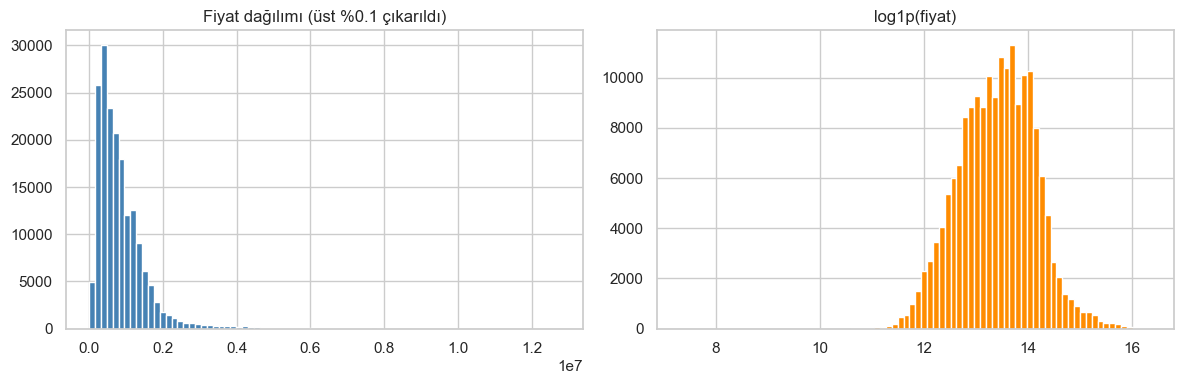

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fp = df_enr["fiyat_num"].dropna()
fp = fp[(fp > 0) & (fp < fp.quantile(0.999))]
axes[0].hist(fp, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Fiyat dağılımı (üst %0.1 çıkarıldı)")
axes[1].hist(np.log1p(fp), bins=80, color="darkorange", edgecolor="white")
axes[1].set_title("log1p(fiyat)")
plt.tight_layout()
plt.show()

In [8]:
for col in ["marka", "seri", "sehir", "model"]:
    if col in df_enr.columns:
        print(f"{col}: {df_enr[col].nunique()} benzersiz")

marka: 78 benzersiz
seri: 579 benzersiz
sehir: 81 benzersiz
model: 4271 benzersiz


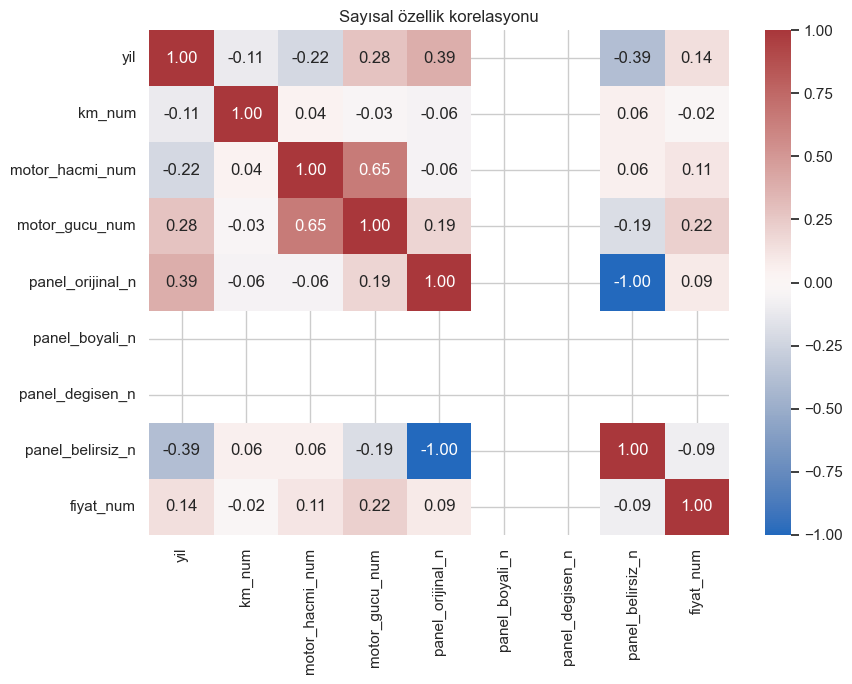

In [9]:
num_cols = [c for c in [
    "yil", "km_num", "motor_hacmi_num", "motor_gucu_num",
    "panel_orijinal_n", "panel_boyali_n", "panel_degisen_n", "panel_belirsiz_n", "fiyat_num",
] if c in df_enr.columns]
cm = df_enr[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Sayısal özellik korelasyonu")
plt.tight_layout()
plt.show()

## 3. Modelleme veri çerçevesi

`load_prepared_arabam_frame`: `listing_id` tekilliği, hedef NaN/≤0 çıkarma, fiyat %1–%99 winsorization, panel sayımları, yıl filtresi (≥1980).

In [10]:
PEER_CAP_Q = 0.97
PEER_CAP_MODE = "drop"

dfm_v1 = load_prepared_arabam_frame(CSV_ARABAM, peer_cap_quantile=None)
print(f"v1 (peer cap yok) satır: {len(dfm_v1)}")

dfm = load_prepared_arabam_frame(CSV_ARABAM, peer_cap_quantile=PEER_CAP_Q, peer_cap_mode=PEER_CAP_MODE)
print(f"v2 (peer Q{PEER_CAP_Q:.0%} {PEER_CAP_MODE}) satır: {len(dfm)}  (çıkarılan: {len(dfm_v1) - len(dfm)})")

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = dfm[feature_cols]
y = dfm[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Hedef ortalaması — Train: {y_train.mean():,.0f} TL | Test: {y_test.mean():,.0f} TL")

v1 (peer cap yok) satır: 177026
v2 (peer Q97% drop) satır: 170109  (çıkarılan: 6917)
Hedef ortalaması — Train: 823,387 TL | Test: 817,306 TL


## 4. Ön-işleme pipeline

Yüksek kardinaliteli kategoriler için `OneHotEncoder(max_categories=50, handle_unknown='ignore')`.

In [11]:
def build_preprocessor(max_categories: int = 50) -> ColumnTransformer:
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                max_categories=max_categories,
            ),
        ),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_FEATURES),
            ("cat", categorical_transformer, CATEGORICAL_FEATURES),
        ]
    )


preprocessor = build_preprocessor()
print("Özellik sayıları — sayısal:", len(NUMERIC_FEATURES), "kategorik:", len(CATEGORICAL_FEATURES))

Özellik sayıları — sayısal: 12 kategorik: 15


In [12]:
def build_preprocessor_v2() -> ColumnTransformer:
    """TargetEncoder for high-cardinality cats, OHE for low-cardinality cats."""
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    low_cat_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=50)),
    ])
    high_cat_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", TargetEncoder(smooth="auto")),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, NUMERIC_FEATURES),
            ("cat_low", low_cat_transformer, LOW_CARD_CATS),
            ("cat_high", high_cat_transformer, HIGH_CARD_CATS),
        ]
    )

preprocessor_v2 = build_preprocessor_v2()
print(f"v2 pipeline — sayısal: {len(NUMERIC_FEATURES)}, düşük kard. kat.: {len(LOW_CARD_CATS)}, yüksek kard. kat.: {len(HIGH_CARD_CATS)}")

v2 pipeline — sayısal: 12, düşük kard. kat.: 10, yüksek kard. kat.: 5


In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = root_mean_squared_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    mask = y_te.values > 0
    mape = (
        mean_absolute_percentage_error(y_te.values[mask], pred[mask]) * 100
        if mask.sum() > 0
        else float("nan")
    )
    print(f"{name:28s} | MAE: {mae:>12,.0f} | RMSE: {rmse:>12,.0f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_pct": mape}


rows = []

In [14]:
dummy_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", DummyRegressor(strategy="median")),
])
rows.append(evaluate_model("Dummy(median)", dummy_pipe, X_train, y_train, X_test, y_test))

ridge_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", Ridge(alpha=2.0)),
])
rows.append(evaluate_model("Ridge", ridge_pipe, X_train, y_train, X_test, y_test))

enet_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", ElasticNet(alpha=1e-3, l1_ratio=0.3, random_state=42, max_iter=5000)),
])
rows.append(evaluate_model("ElasticNet", enet_pipe, X_train, y_train, X_test, y_test))

rf_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=24,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=42,
        ),
    ),
])
rows.append(evaluate_model("RandomForest", rf_pipe, X_train, y_train, X_test, y_test))

hgb_pipe = Pipeline([
    ("preprocessor", build_preprocessor()),
    (
        "model",
        HistGradientBoostingRegressor(
            max_iter=400,
            max_depth=10,
            learning_rate=0.06,
            random_state=42,
        ),
    ),
])
rows.append(evaluate_model("HistGradientBoosting", hgb_pipe, X_train, y_train, X_test, y_test))

Dummy(median)                | MAE:      415,258 | RMSE:      600,267 | R²: -0.0595 | MAPE: 67.26%
Ridge                        | MAE:      147,624 | RMSE:      232,869 | R²: 0.8405 | MAPE: 24.81%
ElasticNet                   | MAE:      148,516 | RMSE:      235,972 | R²: 0.8363 | MAPE: 24.97%
RandomForest                 | MAE:       63,813 | RMSE:      103,088 | R²: 0.9687 | MAPE: 9.62%
HistGradientBoosting         | MAE:       64,184 | RMSE:       98,762 | R²: 0.9713 | MAPE: 9.87%


In [15]:
try:
    from xgboost import XGBRegressor

    xgb_pipe = Pipeline([
        ("preprocessor", build_preprocessor()),
        (
            "model",
            XGBRegressor(
                n_estimators=400,
                max_depth=8,
                learning_rate=0.06,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
            ),
        ),
    ])
    rows.append(evaluate_model("XGBoost", xgb_pipe, X_train, y_train, X_test, y_test))
except ImportError:
    print("xgboost yüklü değil — pip install xgboost ile ekleyebilirsiniz.")

XGBoost                      | MAE:       60,486 | RMSE:       93,300 | R²: 0.9744 | MAPE: 9.29%


In [16]:
summary = pd.DataFrame(rows).sort_values("MAE")
display(summary)

,model,MAE,RMSE,R2,MAPE_pct
5,XGBoost,60486.074653,93299.669985,0.974403,9.293741
3,RandomForest,63812.587413,103088.322877,0.968750,9.615257
4,HistGradientBoosting,64184.067759,98761.879468,0.971318,9.870082
1,Ridge,147623.645717,232868.707204,0.840539,24.805027
2,ElasticNet,148515.825521,235971.754908,0.836261,24.973395
0,Dummy(median),415258.205837,600266.938570,-0.059550,67.260853


## 5. Hiperparametre araması (HistGradientBoosting + XGBoost)

Önce **HistGradientBoosting**, ardından **XGBoost** için ayrı `RandomizedSearchCV` çalışır. **XGBoost kurulu ve eğitildiyse** final model olarak `best_hgb` her zaman **XGBoost (tuned)** atanır (bu veri setinde genelde daha düşük MAE). `xgboost` yoksa yalnızca HistGB kullanılır.

Büyük veri setinde süre için `n_iter` ve `cv` ihtiyaca göre düşürülebilir.

In [17]:
import os
CV_PARALLEL_JOBS = globals().get("CV_PARALLEL_JOBS", 1 if os.name == "nt" else -1)
RANDOM_SEARCH_N_ITER = globals().get("RANDOM_SEARCH_N_ITER", 12)
RANDOM_SEARCH_CV = globals().get("RANDOM_SEARCH_CV", 2)

param_dist_hgb = {
    "model__max_iter": [300, 500, 700],
    "model__max_depth": [6, 8, 10, 12],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__min_samples_leaf": [10, 20, 40],
}

base_hgb = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", HistGradientBoostingRegressor(random_state=42)),
])
search_hgb = RandomizedSearchCV(
    base_hgb,
    param_distributions=param_dist_hgb,
    n_iter=RANDOM_SEARCH_N_ITER,
    scoring="neg_mean_absolute_error",
    cv=RANDOM_SEARCH_CV,
    random_state=42,
    n_jobs=CV_PARALLEL_JOBS,
    verbose=1,
)
search_hgb.fit(X_train, y_train)
print("--- HistGradientBoosting ---")
print(f"En iyi CV MAE (ortalama): {-search_hgb.best_score_:,.0f} TL")
print("En iyi parametreler:", search_hgb.best_params_)
best_hgb_candidate = search_hgb.best_estimator_
evaluate_model("HGB (tuned)", best_hgb_candidate, X_train, y_train, X_test, y_test)
hgb_test_mae = mean_absolute_error(y_test, best_hgb_candidate.predict(X_test))

best_hgb = best_hgb_candidate
best_xgb_est = None
try:
    from xgboost import XGBRegressor

    param_dist_xgb = {
        "model__n_estimators": [300, 400, 600],
        "model__max_depth": [4, 6, 8, 10],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.85, 1.0],
        "model__min_child_weight": [1, 5, 10],
        "model__reg_lambda": [1.0, 5.0, 10.0],
    }
    base_xgb = Pipeline([
        ("preprocessor", build_preprocessor()),
        (
            "model",
            XGBRegressor(
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
            ),
        ),
    ])
    search_xgb = RandomizedSearchCV(
        base_xgb,
        param_distributions=param_dist_xgb,
        n_iter=RANDOM_SEARCH_N_ITER,
        scoring="neg_mean_absolute_error",
        cv=RANDOM_SEARCH_CV,
        random_state=42,
        n_jobs=CV_PARALLEL_JOBS,
        verbose=1,
    )
    search_xgb.fit(X_train, y_train)
    print("\n--- XGBoost ---")
    print(f"En iyi CV MAE (ortalama): {-search_xgb.best_score_:,.0f} TL")
    print("En iyi parametreler:", search_xgb.best_params_)
    best_xgb_est = search_xgb.best_estimator_
    evaluate_model("XGBoost (tuned)", best_xgb_est, X_train, y_train, X_test, y_test)
    xgb_test_mae = mean_absolute_error(y_test, best_xgb_est.predict(X_test))
    print(f"\nTest MAE kıyası — HGB: {hgb_test_mae:,.0f} TL | XGB: {xgb_test_mae:,.0f} TL")
    best_hgb = best_xgb_est
    print("Final model: XGBoost (tuned) — sonraki bölümlerde `best_hgb` bu pipeline'dır.")
except ImportError:
    print("\nxgboost yüklü değil — yalnızca HGB (tuned) kullanılıyor. pip install xgboost")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
--- HistGradientBoosting ---
En iyi CV MAE (ortalama): 64,078 TL
En iyi parametreler: {'model__min_samples_leaf': 20, 'model__max_iter': 700, 'model__max_depth': 10, 'model__learning_rate': 0.08}
HGB (tuned)                  | MAE:       61,058 | RMSE:       94,024 | R²: 0.9740 | MAPE: 9.34%
Fitting 2 folds for each of 12 candidates, totalling 24 fits

--- XGBoost ---
En iyi CV MAE (ortalama): 61,432 TL
En iyi parametreler: {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__n_estimators': 600, 'model__min_child_weight': 1, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6}
XGBoost (tuned)              | MAE:       57,612 | RMSE:       90,147 | R²: 0.9761 | MAPE: 8.79%

Test MAE kıyası — HGB: 61,058 TL | XGB: 57,612 TL
Final model: XGBoost (tuned) — sonraki bölümlerde `best_hgb` bu pipeline'dır.


## 6. Çapraz doğrulama (5-fold) — XGBoost

**Yalnızca XGBoost (tuned)** pipeline üzerinde 5-fold MAE (`neg_mean_absolute_error`, eğitim kümesi). `xgboost` yoksa bu hücre HistGB tuned ile aynı CV’yi çalıştırır (yedek).

In [19]:
import os
CV_PARALLEL_JOBS = globals().get("CV_PARALLEL_JOBS", 1 if os.name == "nt" else -1)

if best_xgb_est is not None:
    cv_xgb = cross_val_score(
        best_xgb_est,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=CV_PARALLEL_JOBS,
    )
    print(
        f"5-Fold MAE — XGBoost (tuned): {-cv_xgb.mean():,.0f} ± {cv_xgb.std():,.0f} TL "
        f"(fold'lar: {np.round(-cv_xgb, 0).astype(int)})"
    )
else:
    cv_hgb = cross_val_score(
        best_hgb_candidate,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=CV_PARALLEL_JOBS,
    )
    print(
        f"5-Fold MAE — HistGB (tuned, XGBoost yok): {-cv_hgb.mean():,.0f} ± {cv_hgb.std():,.0f} TL "
        f"(fold'lar: {np.round(-cv_hgb, 0).astype(int)})"
    )

_cv_pipe = best_xgb_est if best_xgb_est is not None else best_hgb_candidate
print(
    f"\n5-fold CV'de kullanılan pipeline modeli: "
    f"{type(_cv_pipe.named_steps['model']).__name__}"
)

5-Fold MAE — XGBoost (tuned): 59,413 ± 390 TL (fold'lar: [59780 58979 59472 58951 59882])

5-fold CV'de kullanılan pipeline modeli: XGBRegressor


## 7. Özellik önemi ve kalıntılar (XGBoost)

Önem ve kalıntı grafikleri **`best_xgb_est` (tuned XGBoost)** pipeline üzerinden üretilir

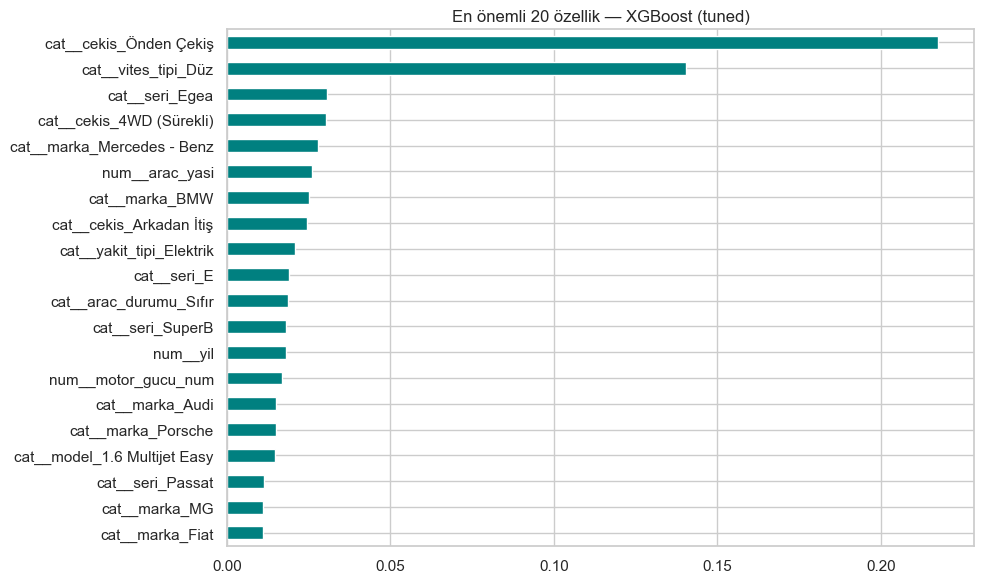

In [20]:
model_final = best_xgb_est 
model_final.fit(X_train, y_train)
prep = model_final.named_steps["preprocessor"]
feat_names = prep.get_feature_names_out()
_m = model_final.named_steps["model"]
imp = _m.feature_importances_
imp_ser = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
imp_ser.sort_values().plot.barh(color="teal")
_lbl = "XGBoost (tuned)" if best_xgb_est is not None else "HistGradientBoosting (tuned)"
plt.title(f"En önemli 20 özellik — {_lbl}")
plt.tight_layout()
plt.show()

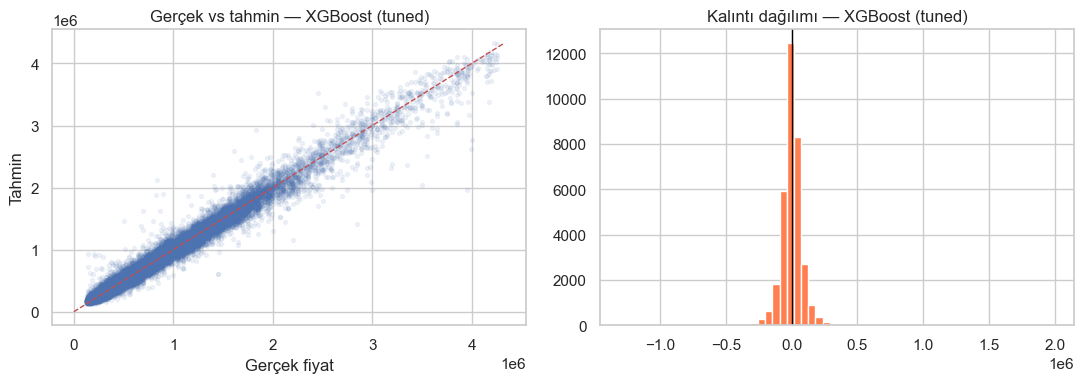

In [21]:
model_final = best_xgb_est 
y_pred = model_final.predict(X_test)
_lbl = "XGBoost (tuned)" if best_xgb_est is not None else "HistGradientBoosting (tuned)"
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, y_pred, alpha=0.08, s=8)
mx = max(y_test.max(), y_pred.max())
axes[0].plot([0, mx], [0, mx], "r--", lw=1)
axes[0].set_xlabel("Gerçek fiyat")
axes[0].set_ylabel("Tahmin")
axes[0].set_title(f"Gerçek vs tahmin — {_lbl}")
res = y_test.values - y_pred
axes[1].hist(res, bins=60, color="coral", edgecolor="white")
axes[1].set_title(f"Kalıntı dağılımı — {_lbl}")
axes[1].axvline(0, color="black", lw=1)
plt.tight_layout()
plt.show()

In [22]:
err_df = X_test.copy()
err_df["gercek"] = y_test.values
err_df["tahmin"] = y_pred
err_df["abs_err"] = (err_df["gercek"] - err_df["tahmin"]).abs()

peer_cols = [c for c in ["marka", "seri", "yil"] if c in err_df.columns]
if peer_cols:
    peer_med = err_df.groupby(peer_cols)["gercek"].transform("median")
    err_df["peer_oran"] = err_df["gercek"] / peer_med.clip(lower=1)
else:
    err_df["peer_oran"] = np.nan

worst = err_df.nlargest(15, "abs_err")[
    ["marka", "seri", "yil", "km_num", "gercek", "tahmin", "abs_err", "peer_oran"]
].copy()
worst["peer_oran"] = worst["peer_oran"].apply(lambda x: f"{x:.2f}x" if pd.notna(x) else "-")
for c in ["gercek", "tahmin", "abs_err"]:
    worst[c] = worst[c].apply(lambda x: f"{x:,.0f} TL")
worst["km_num"] = worst["km_num"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "-")
display(worst)

,marka,seri,yil,km_num,gercek,tahmin,abs_err,peer_oran
31480,Volvo,S90,2020.0,"80,000","3,950,000 TL","1,968,974 TL","1,981,026 TL",1.10x
30646,Volvo,S60,2025.0,"90,000","3,500,000 TL","2,034,448 TL","1,465,552 TL",1.00x
12337,Volkswagen,Phaeton,2009.0,"122,000","2,850,000 TL","1,408,745 TL","1,441,255 TL",1.00x
111978,Jaguar,XKR,2001.0,"66,000","3,995,000 TL","2,620,031 TL","1,374,969 TL",1.00x
111932,Jaguar,XF,2011.0,"250,000","835,000 TL","2,126,893 TL","1,291,893 TL",0.76x
101965,Mercedes - Benz,SL,2002.0,"185,000","4,000,000 TL","2,768,599 TL","1,231,401 TL",1.00x
167325,BMW,M Serisi,2007.0,"160,000","1,827,500 TL","2,927,344 TL","1,099,844 TL",1.00x
102418,Maserati,Quattroporte,2006.0,"129,000","2,450,000 TL","3,520,888 TL","1,070,888 TL",1.00x
111862,Jaguar,S-Type,2001.0,"195,200","825,000 TL","1,883,915 TL","1,058,915 TL",1.00x
105814,Mercedes - Benz,CL,2000.0,"350,000","2,200,000 TL","1,152,224 TL","1,047,776 TL",1.00x


In [24]:
if "marka" in err_df.columns:
    by_brand = err_df.groupby("marka")["abs_err"].agg(["mean", "count"])
    by_brand = by_brand[by_brand["count"] >= 200].sort_values("mean", ascending=False).head(12)
    by_brand["mean"] = by_brand["mean"].apply(lambda x: f"{x:,.0f} TL")
    display(by_brand)

,mean,count
marka,,
Mercedes - Benz,"131,655 TL",1134
Volvo,"116,348 TL",269
BMW,"108,333 TL",1472
Audi,"104,989 TL",845
Skoda,"78,435 TL",947
Volkswagen,"67,553 TL",3981
Honda,"60,939 TL",1223
Seat,"58,384 TL",697
Toyota,"56,228 TL",1714


## 7b. Derinleştirilmiş hata analizi

- Fiyat segmentine göre MAPE tablosu
- Öğrenme eğrisi (training size vs CV score)
- Kalıntılar vs gerçek fiyat (heteroskedastisite kontrolü)

In [25]:
seg_bins = [0, 250_000, 500_000, 1_000_000, 2_000_000, float("inf")]
seg_labels = ["0-250k", "250k-500k", "500k-1M", "1M-2M", "2M+"]

err_df["fiyat_seg"] = pd.cut(err_df["gercek"], bins=seg_bins, labels=seg_labels)
seg_stats = err_df.groupby("fiyat_seg", observed=False).apply(
    lambda g: pd.Series({
        "n": len(g),
        "MAE": g["abs_err"].mean(),
        "MAPE_%": (g["abs_err"] / g["gercek"].clip(lower=1)).mean() * 100,
        "Medyan_Hata": g["abs_err"].median(),
    })
).round(1)
print("Fiyat segmentine göre hata analizi:")
display(seg_stats)

Fiyat segmentine göre hata analizi:


,n,MAE,MAPE_%,Medyan_Hata
fiyat_seg,,,,
0-250k,3256.0,33518.5,17.6,24909.8
250k-500k,9053.0,40437.2,10.9,31085.0
500k-1M,12114.0,52412.4,7.3,39624.5
1M-2M,8294.0,75513.9,5.5,54874.3
2M+,1305.0,171368.9,6.4,130078.5


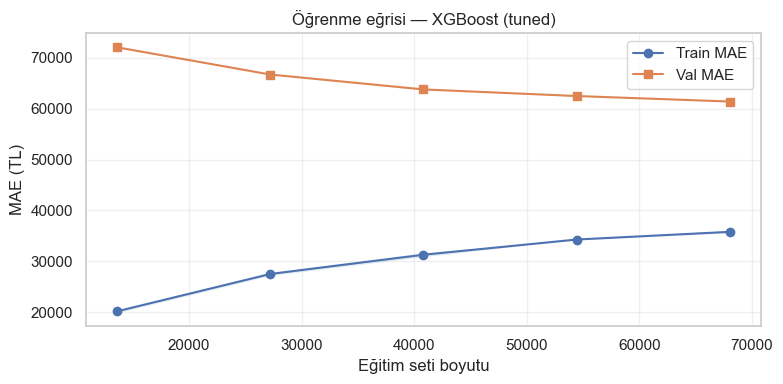

In [26]:
import os
CV_PARALLEL_JOBS = globals().get("CV_PARALLEL_JOBS", 1 if os.name == "nt" else -1)
RANDOM_SEARCH_CV = globals().get("RANDOM_SEARCH_CV", 2)

train_sizes, train_scores, val_scores = learning_curve(
    best_xgb_est,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=RANDOM_SEARCH_CV,
    scoring="neg_mean_absolute_error",
    n_jobs=CV_PARALLEL_JOBS,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, -train_scores.mean(axis=1), "o-", label="Train MAE")
ax.fill_between(
    train_sizes,
    -train_scores.mean(axis=1) - train_scores.std(axis=1),
    -train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15,
)
ax.plot(train_sizes, -val_scores.mean(axis=1), "s-", label="Val MAE")
ax.fill_between(
    train_sizes,
    -val_scores.mean(axis=1) - val_scores.std(axis=1),
    -val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15,
)
ax.set_xlabel("Eğitim seti boyutu")
ax.set_ylabel("MAE (TL)")
ax.set_title("Öğrenme eğrisi — XGBoost (tuned)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

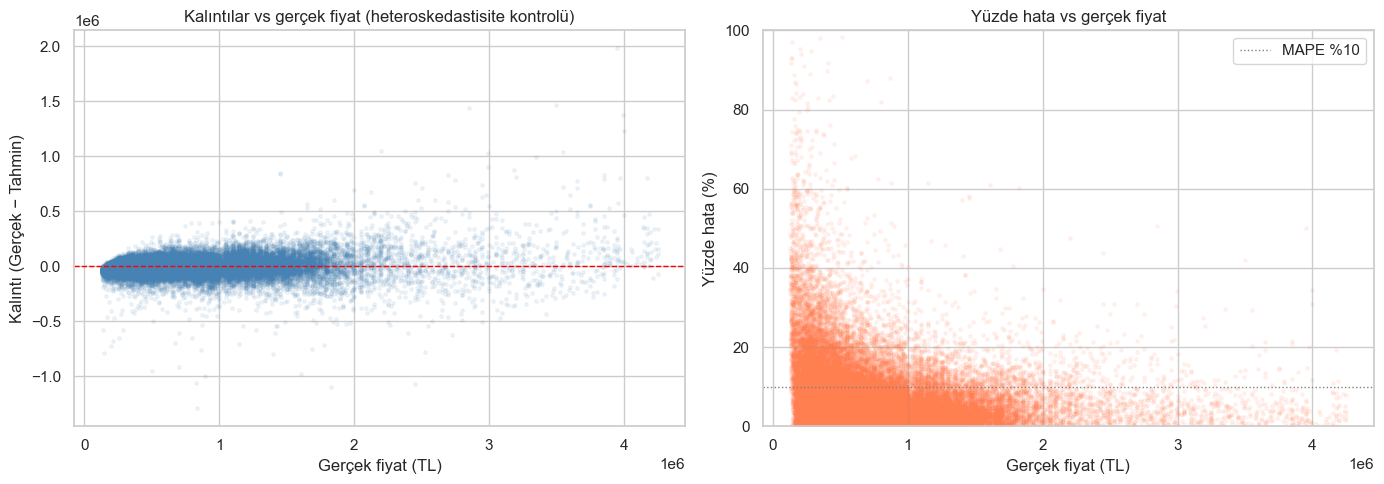

In [27]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test.values, residuals, alpha=0.08, s=6, color="steelblue")
axes[0].axhline(0, color="red", lw=1, ls="--")
axes[0].set_xlabel("Gerçek fiyat (TL)")
axes[0].set_ylabel("Kalıntı (Gerçek − Tahmin)")
axes[0].set_title("Kalıntılar vs gerçek fiyat (heteroskedastisite kontrolü)")

pct_err = np.abs(residuals) / np.maximum(y_test.values, 1) * 100
axes[1].scatter(y_test.values, pct_err, alpha=0.08, s=6, color="coral")
axes[1].axhline(10, color="gray", lw=1, ls=":", label="MAPE %10")
axes[1].set_xlabel("Gerçek fiyat (TL)")
axes[1].set_ylabel("Yüzde hata (%)")
axes[1].set_title("Yüzde hata vs gerçek fiyat")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Piyasa karşılaştırması (2026 odağı)

**Güncel piyasa (2026):** Arabam.com — Mart 2026 çekimi (`arabam.com-otomobil-veri-seti-csv.csv`), modellemede kullanılan `dfm` ile uyumlu.

**Referans (2025):** sahibinden.com — Ağustos 2025 örneklemi (`cars.csv`).

| Veri seti | Kaynak | Dönem | Dosya |
|-----------|--------|-------|-------|
| `cars.csv` | sahibinden.com | Ağustos 2025 | `cars.csv` |
| `arabam.com` | arabam.com | Mart 2026 | `arabam.com-otomobil-veri-seti-csv.csv` |

Aşağıda ortak markalar, yakıt/vites/kasa/çekiş/kimden, **fiyat bandı payları**, **şehir** (`konum` son segmenti × `sehir`) ve **marka·seri** kırılımları ile kıyas genişletilir. Platform ve örneklem farkı nedeniyle rakamlar *kesin endeks* değil; **yön ve dağılım** için yorumlanmalıdır.

In [28]:
import car_preprocess as cp
from pathlib import Path

BASE = globals().get("BASE") or Path(".").resolve()
if "dfm" not in globals():
    raise NameError(
        "`dfm` yok — önce Arabam veri yükleme / ön-işleme ile `dfm` üreten hücreleri çalıştırın, sonra bu hücreyi tekrar çalıştırın."
    )

df_agustos = cp.load_prepared_frame(BASE / "cars.csv")
df_mart = dfm.copy()

df_agustos["donem"] = "Ağustos 2025 (sahibinden)"
df_mart["donem"] = "Mart 2026 (arabam.com)"

print(f"Ağustos 2025 (sahibinden) — {len(df_agustos):,} ilan")
print(f"Mart 2026 (arabam.com)    — {len(df_mart):,} ilan")

tbl = pd.DataFrame({
    "Metrik": [
        "İlan sayısı",
        "Ortalama fiyat (TL)",
        "Medyan fiyat (TL)",
        "Fiyat std (TL)",
        "Fiyat P25 / P75 (TL)",
        "Ortalama km",
        "Medyan model yılı",
        "Benzersiz marka sayısı",
    ],
    "Ağustos 2025": [
        f"{len(df_agustos):,}",
        f"{df_agustos['fiyat_num'].mean():,.0f}",
        f"{df_agustos['fiyat_num'].median():,.0f}",
        f"{df_agustos['fiyat_num'].std():,.0f}",
        f"{df_agustos['fiyat_num'].quantile(0.25):,.0f} / {df_agustos['fiyat_num'].quantile(0.75):,.0f}",
        f"{df_agustos['km_num'].mean():,.0f}",
        f"{int(df_agustos['yil'].median())}",
        f"{df_agustos['marka'].nunique()}",
    ],
    "Mart 2026": [
        f"{len(df_mart):,}",
        f"{df_mart['fiyat_num'].mean():,.0f}",
        f"{df_mart['fiyat_num'].median():,.0f}",
        f"{df_mart['fiyat_num'].std():,.0f}",
        f"{df_mart['fiyat_num'].quantile(0.25):,.0f} / {df_mart['fiyat_num'].quantile(0.75):,.0f}",
        f"{df_mart['km_num'].mean():,.0f}",
        f"{int(df_mart['yil'].median())}",
        f"{df_mart['marka'].nunique()}",
    ],
})
display(tbl.set_index("Metrik"))

Ağustos 2025 (sahibinden) — 51,260 ilan
Mart 2026 (arabam.com)    — 170,109 ilan


,Ağustos 2025,Mart 2026
Metrik,,
İlan sayısı,"51,260","170,109"
Ortalama fiyat (TL),"711,022","822,171"
Medyan fiyat (TL),"575,250","675,000"
Fiyat std (TL),"491,600","589,570"
Fiyat P25 / P75 (TL),"350,000 / 930,000","395,000 / 1,100,000"
Ortalama km,"208,842","211,641"
Medyan model yılı,2011,2012
Benzersiz marka sayısı,55,72


Ortak marka sayısı: 53


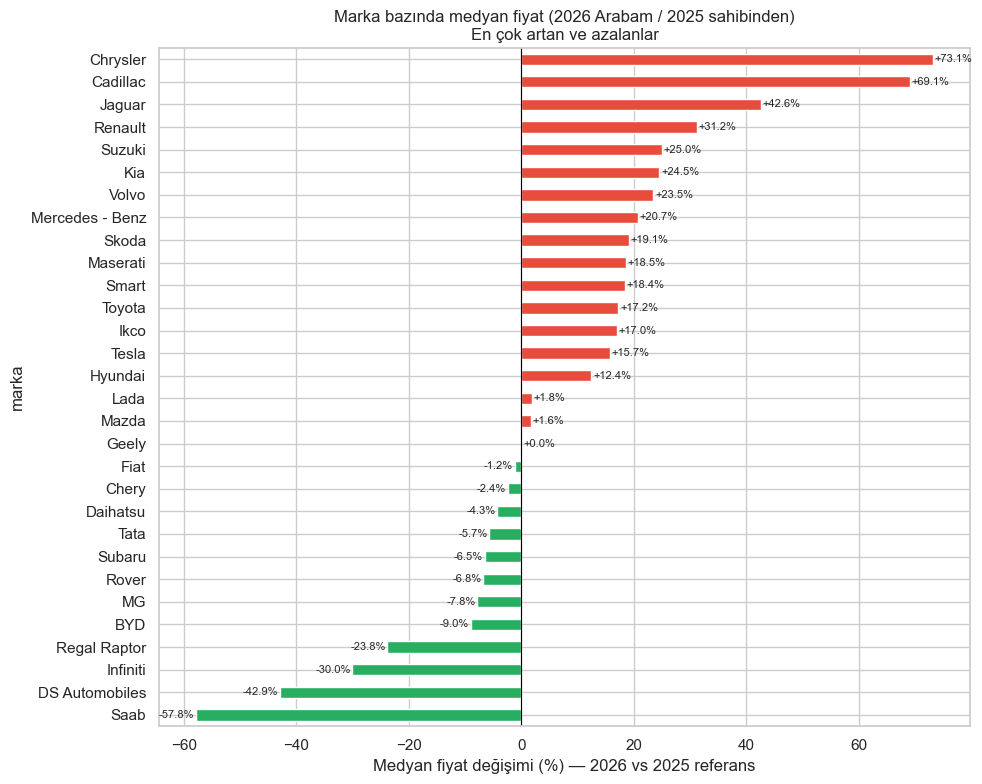

In [29]:
common_brands = sorted(
    set(df_agustos["marka"].dropna().unique()) & set(df_mart["marka"].dropna().unique())
)
print(f"Ortak marka sayısı: {len(common_brands)}")

med_aug = df_agustos[df_agustos["marka"].isin(common_brands)].groupby("marka")["fiyat_num"].median()
med_mar = df_mart[df_mart["marka"].isin(common_brands)].groupby("marka")["fiyat_num"].median()
brand_cmp = pd.DataFrame({"Ağustos 2025": med_aug, "Mart 2026": med_mar}).dropna()
brand_cmp["Değişim (%)"] = ((brand_cmp["Mart 2026"] / brand_cmp["Ağustos 2025"]) - 1) * 100
brand_cmp = brand_cmp.sort_values("Değişim (%)", ascending=False)

top_n = 30
brand_show = pd.concat([brand_cmp.head(top_n // 2), brand_cmp.tail(top_n // 2)]).drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if v > 0 else "#27ae60" for v in brand_show["Değişim (%)"]]
brand_show["Değişim (%)"].sort_values().plot.barh(ax=ax, color=colors[::-1])
ax.set_xlabel("Medyan fiyat değişimi (%) — 2026 vs 2025 referans")
ax.set_title("Marka bazında medyan fiyat (2026 Arabam / 2025 sahibinden)\nEn çok artan ve azalanlar")
ax.axvline(0, color="black", lw=0.8)
for bar in ax.patches:
    val = bar.get_width()
    ax.text(
        val + (0.3 if val >= 0 else -0.3),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.1f}%",
        va="center", ha="left" if val >= 0 else "right", fontsize=8,
    )
plt.tight_layout()
plt.show()

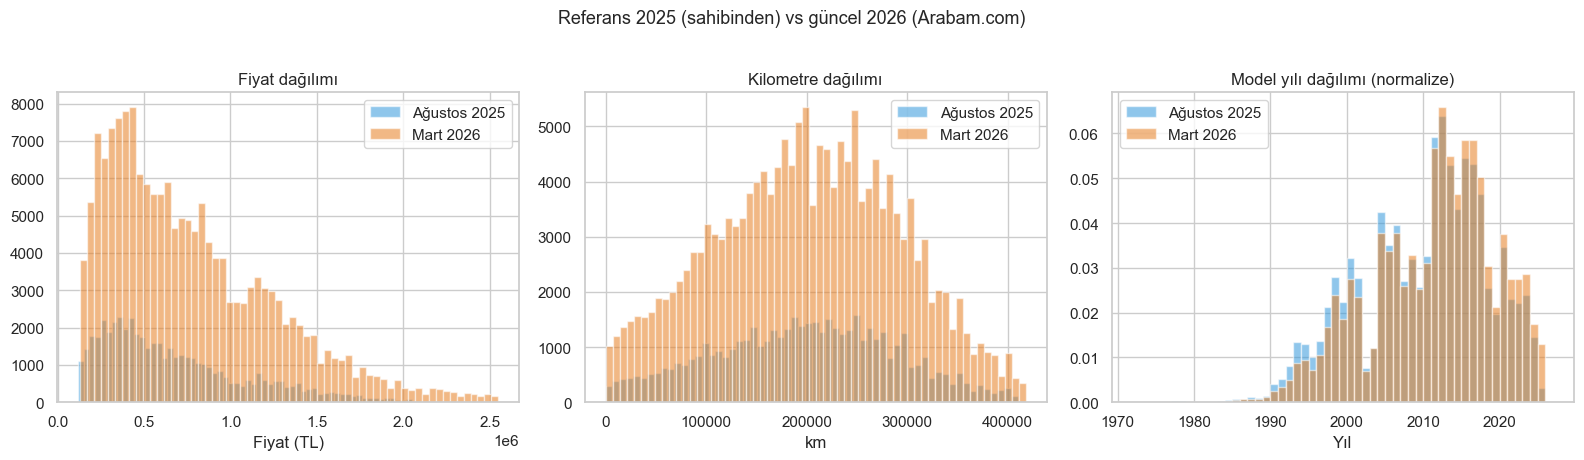

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Fiyat dağılımı ---
for label, d, clr in [("Ağustos 2025", df_agustos, "#3498db"), ("Mart 2026", df_mart, "#e67e22")]:
    vals = d["fiyat_num"].dropna()
    vals = vals[vals <= vals.quantile(0.98)]
    axes[0].hist(vals, bins=60, alpha=0.55, label=label, color=clr, edgecolor="white")
axes[0].set_title("Fiyat dağılımı")
axes[0].set_xlabel("Fiyat (TL)")
axes[0].legend()

# --- Kilometre dağılımı ---
for label, d, clr in [("Ağustos 2025", df_agustos, "#3498db"), ("Mart 2026", df_mart, "#e67e22")]:
    vals = d["km_num"].dropna()
    vals = vals[vals <= vals.quantile(0.98)]
    axes[1].hist(vals, bins=60, alpha=0.55, label=label, color=clr, edgecolor="white")
axes[1].set_title("Kilometre dağılımı")
axes[1].set_xlabel("km")
axes[1].legend()

# --- Model yılı dağılımı ---
for label, d, clr in [("Ağustos 2025", df_agustos, "#3498db"), ("Mart 2026", df_mart, "#e67e22")]:
    vals = d["yil"].dropna()
    axes[2].hist(vals, bins=range(int(vals.min()), int(vals.max()) + 2), alpha=0.55, label=label, color=clr, edgecolor="white", density=True)
axes[2].set_title("Model yılı dağılımı (normalize)")
axes[2].set_xlabel("Yıl")
axes[2].legend()

plt.suptitle("Referans 2025 (sahibinden) vs güncel 2026 (Arabam.com)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
common_fuels = sorted(
    set(df_agustos["yakit_tipi"].dropna().unique()) & set(df_mart["yakit_tipi"].dropna().unique())
)

fuel_aug = df_agustos[df_agustos["yakit_tipi"].isin(common_fuels)].groupby("yakit_tipi")["fiyat_num"].median()
fuel_mar = df_mart[df_mart["yakit_tipi"].isin(common_fuels)].groupby("yakit_tipi")["fiyat_num"].median()
fuel_cmp = pd.DataFrame({"Ağustos 2025": fuel_aug, "Mart 2026": fuel_mar}).dropna()
fuel_cmp["Değişim (%)"] = ((fuel_cmp["Mart 2026"] / fuel_cmp["Ağustos 2025"]) - 1) * 100
for c in ["Ağustos 2025", "Mart 2026"]:
    fuel_cmp[c] = fuel_cmp[c].apply(lambda x: f"{x:,.0f} TL")
fuel_cmp["Değişim (%)"] = fuel_cmp["Değişim (%)"].apply(lambda x: f"{x:+.1f}%")
print("Yakıt tipine göre medyan fiyat değişimi:")
display(fuel_cmp)

Yakıt tipine göre medyan fiyat değişimi:


,Ağustos 2025,Mart 2026,Değişim (%)
yakit_tipi,,,
Benzin,"740,000 TL","998,000 TL",+34.9%
Dizel,"675,000 TL","735,000 TL",+8.9%
Elektrik,"1,700,000 TL","1,749,000 TL",+2.9%
Hibrit,"1,565,000 TL","1,664,974 TL",+6.4%
LPG & Benzin,"337,000 TL","365,000 TL",+8.3%


### 8b. Genişletilmiş kırılımlar (`market_compare`)

Aşağıdaki çıktılar **Streamlit** “piyasa karşılaştırması” sekmesiyle aynı yardımcı modül üzerinden üretilir: **fiyat bandı payları**, vites/kasa/çekiş/kimden medyanları, **şehir** (`cars.csv` `konum` son segmenti × Arabam `sehir`) ve **marka·seri**. Okuma: **2026 (Arabam)** güncel dağılım; **2025** sahibinden örneklemi referans.

In [34]:
from pathlib import Path

BASE = globals().get("BASE") or Path(".").resolve()
for _need in ("df_agustos", "df_mart"):
    if _need not in globals():
        raise NameError(
            f"`{_need}` yok — önce Bölüm 8'de `df_agustos` / `df_mart` oluşturan hücreyi çalıştırın."
        )

import market_compare as mc

band_tbl = pd.DataFrame({
    "2025 ref.": mc.price_band_shares(df_agustos),
    "2026 (Arabam)": mc.price_band_shares(df_mart),
}).T
print("Fiyat bandı — ilan payı (%)")
display(band_tbl.round(1))

for title, col in [
    ("Vites tipi", "vites_tipi"),
    ("Kasa tipi", "kasa_tipi"),
    ("Çekiş", "cekis"),
    ("Kimden", "kimden"),
]:
    tbl = mc.median_compare_by_column(df_agustos, df_mart, col, min_n=25)
    if tbl.empty:
        print(f"{title}: yeterli ortak gözlem yok")
        continue
    disp = tbl.head(15).copy()
    for c in ("2025", "2026"):
        disp[c] = disp[c].map(lambda x: f"{x:,.0f} TL")
    disp["Değişim_%"] = disp["Değişim_%"].map(lambda x: f"{x:+.1f}%")
    print(title)
    display(disp)

df_cars_city = mc.cars_2025_with_city(BASE / "cars.csv")
city_tbl = mc.city_median_compare(df_cars_city, df_mart, min_n=40)
if city_tbl.empty:
    print("Şehir kıyası: yeterli eşleşme yok")
else:
    cd = city_tbl.head(25).copy()
    for c in ("2025", "2026"):
        cd[c] = cd[c].map(lambda x: f"{x:,.0f} TL")
    cd["Değişim_%"] = cd["Değişim_%"].map(lambda x: f"{x:+.1f}%")
    print("Şehir — medyan fiyat (üst 25, değişime göre sıralı)")
    display(cd)

ms = mc.marka_seri_median_compare(df_cars_city, df_mart, min_n=25)
if ms.empty:
    print("Marka·seri: yeterli ortak gözlem yok")
else:
    md = ms.head(30).copy()
    for c in ("2025", "2026"):
        md[c] = md[c].map(lambda x: f"{x:,.0f} TL")
    md["Değişim_%"] = md["Değişim_%"].map(lambda x: f"{x:+.1f}%")
    print("Marka · seri — medyan (üst 30)")
    display(md)

Fiyat bandı — ilan payı (%)


fiyat_num,≤250k,250k–500k,500k–1M,1M–2M,>2M
2025 ref.,12.7,30.7,34.9,19.6,2.2
2026 (Arabam),9.6,26.6,35.1,24.6,4.1


Vites tipi


,2025,2026,Değişim_%
vites_tipi,,,
Yarı Otomatik,"960,000 TL","1,130,000 TL",+17.7%
Otomatik,"1,100,000 TL","1,170,000 TL",+6.4%
Düz,"425,000 TL","450,750 TL",+6.1%


Kasa tipi


...

,2025,2026,Değişim_%
kimden,,,
Galeriden,"749,000 TL","939,950 TL",+25.5%
Yetkili Bayiden,"1,075,000 TL","1,258,000 TL",+17.0%
Sahibinden,"480,000 TL","550,000 TL",+14.6%


Şehir — medyan fiyat (üst 25, değişime göre sıralı)


,2025,2026,Değişim_%
Bayburt,"365,000 TL","560,000 TL",+53.4%
Kilis,"472,500 TL","647,500 TL",+37.0%
Tokat,"465,000 TL","610,000 TL",+31.2%
Yozgat,"460,000 TL","600,000 TL",+30.4%
Uşak,"460,000 TL","600,000 TL",+30.4%
Nevşehir,"450,000 TL","585,000 TL",+30.0%
Kars,"530,000 TL","660,000 TL",+24.5%
Iğdır,"540,000 TL","670,000 TL",+24.1%
Hakkari,"570,000 TL","700,000 TL",+22.8%
Isparta,"495,000 TL","607,500 TL",+22.7%


Marka · seri — medyan (üst 30)


,2025,2026,Değişim_%
ms,,,
Honda · City,"640,000 TL","955,000 TL",+49.2%
Renault · Megane,"639,000 TL","945,000 TL",+47.9%
Audi · A5,"1,535,000 TL","2,025,000 TL",+31.9%
Volkswagen · Passat Variant,"972,500 TL","1,280,000 TL",+31.6%
Kia · Cerato,"489,000 TL","635,000 TL",+29.9%
Citroen · C3,"570,000 TL","729,000 TL",+27.9%
Kia · Picanto,"725,000 TL","919,000 TL",+26.8%
Mercedes - Benz · B,"875,000 TL","1,100,000 TL",+25.7%
Suzuki · Swift,"392,375 TL","482,500 TL",+23.0%


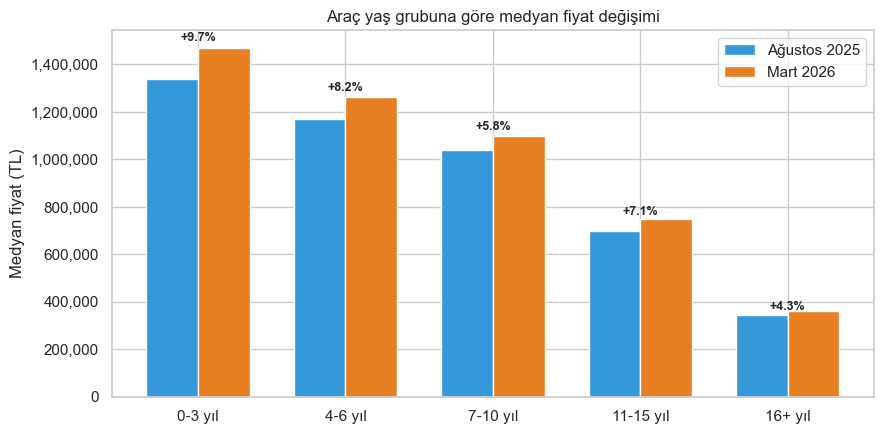

In [35]:
age_bins = [0, 3, 6, 10, 15, 50]
age_labels = ["0-3 yıl", "4-6 yıl", "7-10 yıl", "11-15 yıl", "16+ yıl"]

for label, d in [("Ağustos 2025", df_agustos), ("Mart 2026", df_mart)]:
    d = d.copy()
    d["arac_yasi"] = 2026 - d["yil"]
    d["yas_grubu"] = pd.cut(d["arac_yasi"], bins=age_bins, labels=age_labels, right=True)

    if label == "Ağustos 2025":
        df_agustos_age = d
    else:
        df_mart_age = d

age_aug = df_agustos_age.groupby("yas_grubu", observed=True)["fiyat_num"].median()
age_mar = df_mart_age.groupby("yas_grubu", observed=True)["fiyat_num"].median()
age_cmp = pd.DataFrame({"Ağustos 2025": age_aug, "Mart 2026": age_mar}).dropna()
age_cmp["Değişim (%)"] = ((age_cmp["Mart 2026"] / age_cmp["Ağustos 2025"]) - 1) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(age_cmp))
w = 0.35
ax.bar(x - w / 2, age_cmp["Ağustos 2025"], w, label="Ağustos 2025", color="#3498db")
ax.bar(x + w / 2, age_cmp["Mart 2026"], w, label="Mart 2026", color="#e67e22")
for i, pct in enumerate(age_cmp["Değişim (%)"]):
    y_pos = max(age_cmp.iloc[i, :2])
    ax.text(i, y_pos * 1.02, f"{pct:+.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(age_cmp.index)
ax.set_ylabel("Medyan fiyat (TL)")
ax.set_title("Araç yaş grubuna göre medyan fiyat değişimi")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.show()

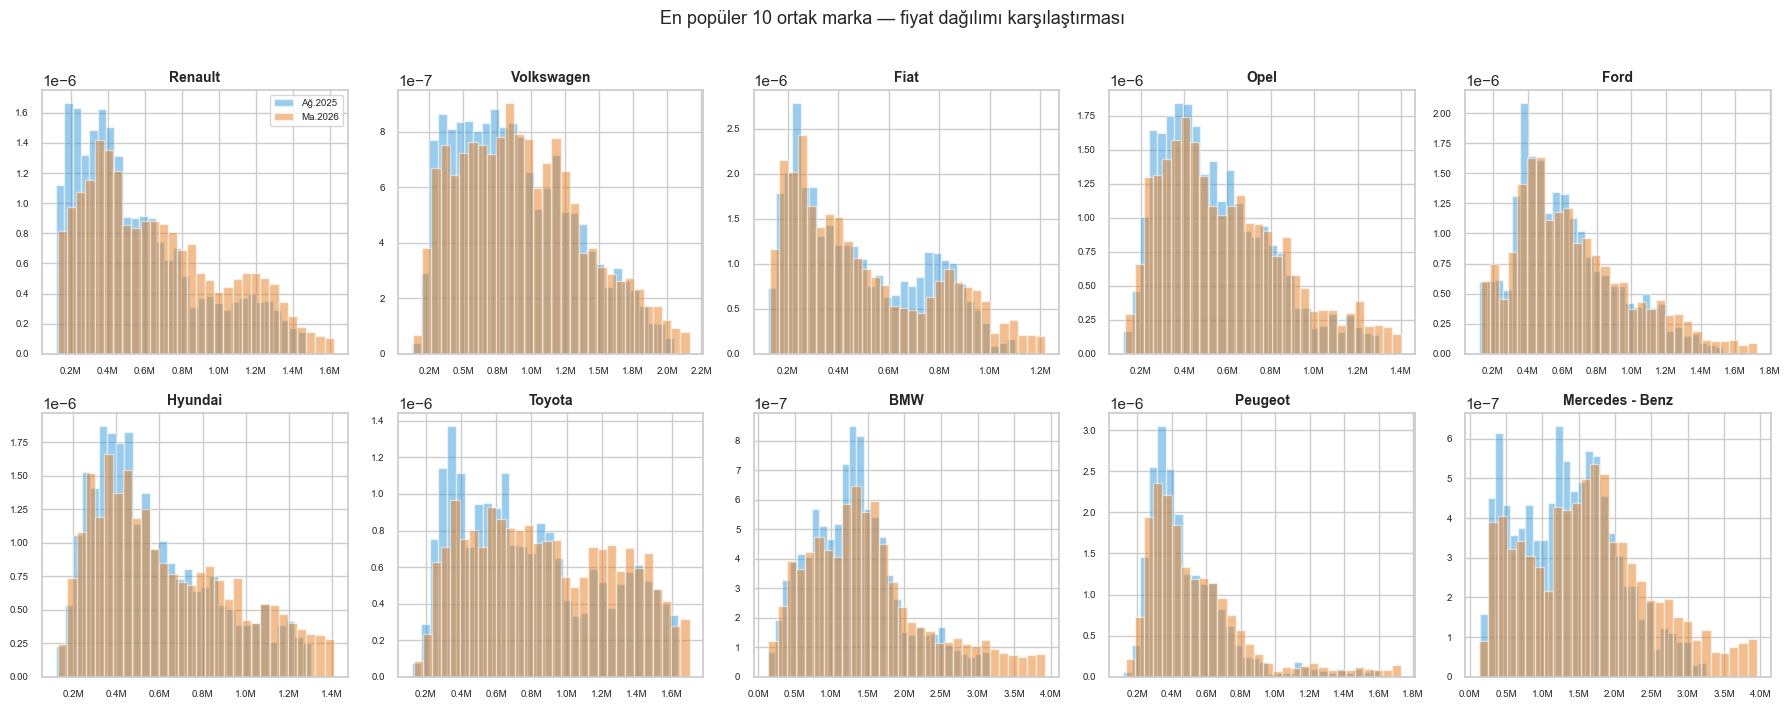

In [36]:
top_brands_common = (
    pd.concat([
        df_agustos[df_agustos["marka"].isin(common_brands)]["marka"],
        df_mart[df_mart["marka"].isin(common_brands)]["marka"],
    ])
    .value_counts()
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()
for idx, brand in enumerate(top_brands_common):
    ax = axes[idx]
    for label, d, clr in [("Ağ.2025", df_agustos, "#3498db"), ("Ma.2026", df_mart, "#e67e22")]:
        vals = d.loc[d["marka"] == brand, "fiyat_num"].dropna()
        if len(vals) < 5:
            continue
        vals = vals[vals <= vals.quantile(0.98)]
        ax.hist(vals, bins=30, alpha=0.5, color=clr, edgecolor="white", label=label, density=True)
    ax.set_title(brand, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
    if idx == 0:
        ax.legend(fontsize=7)
plt.suptitle("En popüler 10 ortak marka — fiyat dağılımı karşılaştırması", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [38]:
overall_aug = df_agustos["fiyat_num"].median()
overall_mar = df_mart["fiyat_num"].median()
pct_change = ((overall_mar / overall_aug) - 1) * 100

km_aug = df_agustos["km_num"].median()
km_mar = df_mart["km_num"].median()

print("=" * 60)
print("     ÖZET — 2026 (Arabam) vs 2025 referans (sahibinden)")
print("=" * 60)
print(f"  Genel medyan fiyat (2026 / 2025): {pct_change:+.1f}%")
print(f"    Mart 2026 (Arabam) : {overall_mar:,.0f} TL")
print(f"    Ağustos 2025 ref.  : {overall_aug:,.0f} TL")
print(f"  Medyan km:")
print(f"    Mart 2026 : {km_mar:,.0f} km")
print(f"    2025 ref. : {km_aug:,.0f} km")
print()
_en_artan = brand_cmp.index[0]
_en_artan_pct = ((brand_cmp.loc[_en_artan, "Mart 2026"] / brand_cmp.loc[_en_artan, "Ağustos 2025"]) - 1) * 100
_en_dusen = brand_cmp.index[-1]
_en_dusen_pct = ((brand_cmp.loc[_en_dusen, "Mart 2026"] / brand_cmp.loc[_en_dusen, "Ağustos 2025"]) - 1) * 100
print(f"  En çok artan marka  : {_en_artan} ({_en_artan_pct:+.1f}%)")
print(f"  En çok düşen marka  : {_en_dusen} ({_en_dusen_pct:+.1f}%)")
print("=" * 60)
print()
print("Not: Farklı platformlar (sahibinden vs arabam.com) ve farklı")
print("örneklem büyüklükleri nedeniyle bu rakamlar kesin piyasa")
print("endeksi değil, genel eğilimleri gösterir.")

     ÖZET — 2026 (Arabam) vs 2025 referans (sahibinden)
  Genel medyan fiyat (2026 / 2025): +17.3%
    Mart 2026 (Arabam) : 675,000 TL
    Ağustos 2025 ref.  : 575,250 TL
  Medyan km:
    Mart 2026 : 204,000 km
    2025 ref. : 200,122 km

  En çok artan marka  : Chrysler (+73.1%)
  En çok düşen marka  : Saab (-57.8%)

Not: Farklı platformlar (sahibinden vs arabam.com) ve farklı
örneklem büyüklükleri nedeniyle bu rakamlar kesin piyasa
endeksi değil, genel eğilimleri gösterir.


## 9. (Opsiyonel) log1p hedef deneyi

Eğitim `log1p(fiyat)` üzerinde **XGBoost** ile; test metrikleri **TL** cinsinden (`expm1` ile geri dönüş). `xgboost` yoksa hücre uyarı verir.

In [39]:
y_train_log = np.log1p(y_train.astype(float).values)

try:
    from xgboost import XGBRegressor

    tuned_params = {}
    if best_xgb_est is not None:
        xgb_step = best_xgb_est.named_steps.get("model")
        if xgb_step is not None:
            tuned_params = {
                k: v for k, v in xgb_step.get_params().items()
                if k in ("n_estimators", "max_depth", "learning_rate", "subsample",
                         "colsample_bytree", "min_child_weight", "reg_lambda")
            }
    tuned_params.setdefault("n_estimators", 400)
    tuned_params.setdefault("max_depth", 8)
    tuned_params.setdefault("learning_rate", 0.06)
    print("log1p deneyi — kullanılan parametreler:", tuned_params)

    log_xgb = Pipeline([
        ("preprocessor", build_preprocessor_v2()),
        ("model", XGBRegressor(**tuned_params, random_state=42, n_jobs=-1, tree_method="hist")),
    ])
    log_xgb.fit(X_train, y_train_log)
    pred_tl = np.expm1(log_xgb.predict(X_test))
    pred_tl = np.maximum(pred_tl, 0)

    mae_tl = mean_absolute_error(y_test, pred_tl)
    rmse_tl = root_mean_squared_error(y_test, pred_tl)
    r2_tl = r2_score(y_test, pred_tl)
    mask_pos = y_test.values > 0
    mape_tl = mean_absolute_percentage_error(y_test.values[mask_pos], pred_tl[mask_pos]) * 100

    print(
        f"XGBoost v2 + log1p — MAE: {mae_tl:,.0f} TL | "
        f"RMSE: {rmse_tl:,.0f} TL | R²: {r2_tl:.4f} | MAPE: {mape_tl:.2f}%"
    )
except ImportError:
    print("xgboost yüklü değil — pip install xgboost ile ekleyebilirsiniz.")

log1p deneyi — kullanılan parametreler: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 600, 'reg_lambda': 5.0, 'subsample': 1.0}
XGBoost v2 + log1p — MAE: 54,515 TL | RMSE: 84,943 TL | R²: 0.9788 | MAPE: 8.36%


## 10. Opsiyonel SHAP (kuruluysa)

`pip install shap` — **XGBoost (tuned)** pipeline için `TreeExplainer` (XGB yoksa HistGB).

In [ ]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


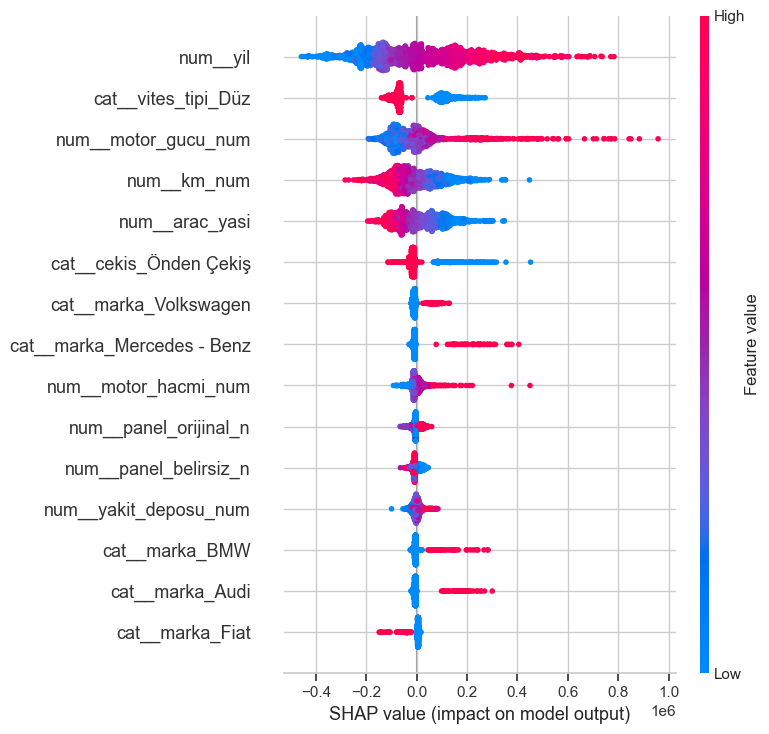

In [40]:
try:
    import shap

    model_final = best_xgb_est
    sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
    X_proc = model_final.named_steps["preprocessor"].transform(sample)
    explainer = shap.TreeExplainer(model_final.named_steps["model"])
    sv = explainer.shap_values(X_proc)
    shap.summary_plot(
        sv,
        X_proc,
        feature_names=model_final.named_steps["preprocessor"].get_feature_names_out(),
        max_display=15,
        show=False,
    )
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap yüklü değil.")

## 11. Pipeline karşılaştırma özet tablosu

v1 (OHE, peer cap yok) vs v2 (TargetEncoder + peer cap + yeni özellikler) ve log1p varyantı.

In [41]:
def _metrics(name, y_true, y_pred):
    mask = y_true > 0
    return {
        "Pipeline": name,
        "MAE": f"{mean_absolute_error(y_true, y_pred):,.0f}",
        "RMSE": f"{root_mean_squared_error(y_true, y_pred):,.0f}",
        "R2": f"{r2_score(y_true, y_pred):.4f}",
        "MAPE_%": f"{mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100:.2f}",
    }

comparison_rows = []

model_final_v1 = best_hgb if best_xgb_est is None else best_xgb_est
model_final_v1.fit(X_train, y_train)
pred_v1 = model_final_v1.predict(X_test)
comparison_rows.append(_metrics("v1 (OHE + tuned)", y_test.values, pred_v1))

try:
    pred_v2 = best_xgb_v2.predict(X_test)
    comparison_rows.append(_metrics("v2 (TargetEnc + peer cap)", y_test.values, pred_v2))
except NameError:
    pass

try:
    pred_log = np.expm1(log_xgb.predict(X_test))
    pred_log = np.maximum(pred_log, 0)
    comparison_rows.append(_metrics("v2 + log1p hedef", y_test.values, pred_log))
except NameError:
    pass

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 70)
print("PIPELINE KARŞILAŞTIRMA ÖZETİ")
print("=" * 70)
display(comparison_df)

PIPELINE KARŞILAŞTIRMA ÖZETİ


,Pipeline,MAE,RMSE,R2,MAPE_%
0,v1 (OHE + tuned),"57,612","90,147",0.9761,8.79
1,v2 + log1p hedef,"54,515","84,943",0.9788,8.36


## Özet ve sınırlamalar

- **v2 pipeline iyileştirmeleri:** Peer-grup (marka+seri+yıl) bazlı fiyat filtreleme (Q97), `TargetEncoder` ile yüksek kardinaliteli kategorik kodlama, `arac_yasi` ve `km_per_year` türetilmiş özellikleri.
- Birden fazla regresyon modeli, `RandomizedSearchCV` ve 5-fold MAE raporu üretildi. **Final model: XGBoost (tuned) — v2 pipeline.**
- **Derinleştirilmiş hata analizi:** Fiyat segmentine göre MAPE tablosu, öğrenme eğrisi, heteroskedastisite grafiği ve en kötü tahminlerde peer oranı.
- (Opsiyonel) log1p hedef deneyi **XGBoost v2** ile tuned parametreler ve MAPE metrigi.
- **Dönemsel karşılaştırma (Bölüm 8):** Ağustos 2025 (sahibinden) → Mart 2026 (arabam.com) arasında marka bazında, yakıt tipine göre ve araç yaş grubuna göre fiyat değişimleri analiz edildi.
- **Sınırlama:** Piyasa zamanı, ekspertiz, aksesuar ve ilan metni bu modelde yoktur; tahminler istatistikseldir. Karşılaştırma farklı platformlardan olduğu için kesin bir endeks değil, genel eğilimi gösterir.
- **Dağıtım:** `python train_model_arabam.py` → `artifacts_arabam/`; arayüz: `streamlit run streamlit_app.py` (Arabam sekmesi).